In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
!apt-get update
!apt-get install -y bedtools bioawk samtools

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,293 kB]
Get:9 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,913 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [61.6 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,995 kB]
Get:13 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packa

In [5]:
%cd /content/drive/MyDrive/binfo1-work/

/content/drive/MyDrive/binfo1-work


In [6]:
!grep '	start_codon	.*	+	.*transcript_support_level "1"' ../binfo1-datapack1/gencode.gtf | \
 sed -e 's/	[^	]*transcript_id "\([^"]*\)".*$/	\1/g' > gencode-start.gtf
!head gencode-start.gtf

chr1	HAVANA	start_codon	4878137	4878139	.	+	0	ENSMUST00000134384.8
chr1	HAVANA	start_codon	4878137	4878139	.	+	0	ENSMUST00000027036.11
chr1	HAVANA	start_codon	4878137	4878139	.	+	0	ENSMUST00000150971.8
chr1	HAVANA	start_codon	4928137	4928139	.	+	0	ENSMUST00000081551.14
chr1	HAVANA	start_codon	5154674	5154676	.	+	0	ENSMUST00000044369.13
chr1	HAVANA	start_codon	5659272	5659274	.	+	0	ENSMUST00000160777.8
chr1	HAVANA	start_codon	5659272	5659274	.	+	0	ENSMUST00000027038.11
chr1	HAVANA	start_codon	6300227	6300229	.	+	0	ENSMUST00000027040.13
chr1	HAVANA	start_codon	6429555	6429557	.	+	0	ENSMUST00000133144.4
chr1	HAVANA	start_codon	6839122	6839124	.	+	0	ENSMUST00000140079.8


In [7]:
!grep '	exon	.*	+	' ../binfo1-datapack1/gencode.gtf | \
 sed -e 's/	[^	]*transcript_id "\([^"]*\)".*$/	\1/g' > gencode-plusexon.gtf
!head gencode-plusexon.gtf

chr1	HAVANA	exon	3143476	3144545	.	+	.	ENSMUST00000193812.2
chr1	ENSEMBL	exon	3172239	3172348	.	+	.	ENSMUST00000082908.3
chr1	HAVANA	exon	3322980	3323459	.	+	.	ENSMUST00000192857.2
chr1	HAVANA	exon	3536810	3536910	.	+	.	ENSMUST00000161581.2
chr1	HAVANA	exon	3583628	3583776	.	+	.	ENSMUST00000161581.2
chr1	HAVANA	exon	3602018	3602943	.	+	.	ENSMUST00000192183.2
chr1	HAVANA	exon	3750378	3752011	.	+	.	ENSMUST00000193244.2
chr1	HAVANA	exon	3822233	3824583	.	+	.	ENSMUST00000194454.2
chr1	HAVANA	exon	4566774	4569601	.	+	.	ENSMUST00000193450.2
chr1	HAVANA	exon	4567697	4567877	.	+	.	ENSMUST00000194935.2


In [12]:
!bedtools intersect -a gencode-start.gtf -b gencode-plusexon.gtf -wa -wb | \
 awk -F'	' -v OFS='	' '$9 == $18 { print $10, $13-1, $14, $18, $4-1, $16; }' | \
 sort -k1,1 -k2,3n -k4,4 > gencode-exons-containing-startcodon.bed
!head gencode-exons-containing-startcodon.bed; tail gencode-exons-containing-startcodon.bed

chr1	4878010	4878205	ENSMUST00000134384.8	4878136	+
chr1	4878045	4878205	ENSMUST00000027036.11	4878136	+
chr1	4878052	4878205	ENSMUST00000150971.8	4878136	+
chr1	4928036	4928199	ENSMUST00000081551.14	4928136	+
chr1	5154639	5154786	ENSMUST00000044369.13	5154673	+
chr1	5659227	5659528	ENSMUST00000027038.11	5659271	+
chr1	5659257	5659528	ENSMUST00000160777.8	5659271	+
chr1	6300182	6300297	ENSMUST00000027040.13	6300226	+
chr1	6429441	6429738	ENSMUST00000133144.4	6429554	+
chr1	6839121	6839176	ENSMUST00000043578.13	6839121	+
chrY	80939672	80939804	ENSMUST00000185340.2	80939686	+
chrY	81470683	81470815	ENSMUST00000187135.2	81470697	+
chrY	82237903	82238035	ENSMUST00000185636.2	82237917	+
chrY	83043623	83043755	ENSMUST00000187165.2	83043637	+
chrY	84109956	84110088	ENSMUST00000185776.7	84109970	+
chrY	84759361	84759493	ENSMUST00000186110.2	84759375	+
chrY	86074448	86074580	ENSMUST00000188754.2	86074462	+
chrY	87129500	87129632	ENSMUST00000189543.7	87129514	+
chrY	87563647	87563779	ENSMUST0000

In [13]:
!(samtools view -H ../binfo1-datapack1/RPF-siLuc.bam; \
  samtools view -F20 ../binfo1-datapack1/RPF-siLuc.bam | \
  bioawk -c sam '{ if (length($seq) >= 25) print $0; }') | \
 samtools view -b -o filtered-RPF-siLuc.bam

In [14]:
!ls -al *RPF-siLuc.bam

-rw------- 1 root root 567739806 May  7 07:38 filtered-RPF-siLuc.bam


In [15]:
!bedtools genomecov -ibam filtered-RPF-siLuc.bam -bg -5 > fivepcounts-RPF-siLuc.bed
!head fivepcounts-RPF-siLuc.bed

chr1	3176534	3176535	1
chr1	3196256	3196257	1
chr1	3221526	3221527	1
chr1	3221542	3221543	2
chr1	3221545	3221546	3
chr1	3221546	3221547	2
chr1	3221548	3221550	1
chr1	3221571	3221572	1
chr1	3221897	3221898	1
chr1	3221994	3221995	1


In [16]:
!bedtools intersect -a fivepcounts-RPF-siLuc.bed -b gencode-exons-containing-startcodon.bed \
 -wa -wb -nonamecheck > fivepcounts-filtered-RPF-siLuc.txt
!head fivepcounts-filtered-RPF-siLuc.txt

chr1	4878048	4878049	1	chr1	4878010	4878205	ENSMUST00000134384.8	4878136	+
chr1	4878048	4878049	1	chr1	4878045	4878205	ENSMUST00000027036.11	4878136	+
chr1	4878077	4878078	1	chr1	4878010	4878205	ENSMUST00000134384.8	4878136	+
chr1	4878077	4878078	1	chr1	4878045	4878205	ENSMUST00000027036.11	4878136	+
chr1	4878077	4878078	1	chr1	4878052	4878205	ENSMUST00000150971.8	4878136	+
chr1	4878101	4878102	4	chr1	4878010	4878205	ENSMUST00000134384.8	4878136	+
chr1	4878101	4878102	4	chr1	4878045	4878205	ENSMUST00000027036.11	4878136	+
chr1	4878101	4878102	4	chr1	4878052	4878205	ENSMUST00000150971.8	4878136	+
chr1	4878103	4878104	1	chr1	4878010	4878205	ENSMUST00000134384.8	4878136	+
chr1	4878103	4878104	1	chr1	4878045	4878205	ENSMUST00000027036.11	4878136	+


ValueError: keyword ha is not recognized; valid keywords are ['size', 'width', 'color', 'tickdir', 'pad', 'labelsize', 'labelcolor', 'labelfontfamily', 'zorder', 'gridOn', 'tick1On', 'tick2On', 'label1On', 'label2On', 'length', 'direction', 'left', 'bottom', 'right', 'top', 'labelleft', 'labelbottom', 'labelright', 'labeltop', 'labelrotation', 'grid_agg_filter', 'grid_alpha', 'grid_animated', 'grid_antialiased', 'grid_clip_box', 'grid_clip_on', 'grid_clip_path', 'grid_color', 'grid_dash_capstyle', 'grid_dash_joinstyle', 'grid_dashes', 'grid_data', 'grid_drawstyle', 'grid_figure', 'grid_fillstyle', 'grid_gapcolor', 'grid_gid', 'grid_in_layout', 'grid_label', 'grid_linestyle', 'grid_linewidth', 'grid_marker', 'grid_markeredgecolor', 'grid_markeredgewidth', 'grid_markerfacecolor', 'grid_markerfacecoloralt', 'grid_markersize', 'grid_markevery', 'grid_mouseover', 'grid_path_effects', 'grid_picker', 'grid_pickradius', 'grid_rasterized', 'grid_sketch_params', 'grid_snap', 'grid_solid_capstyle

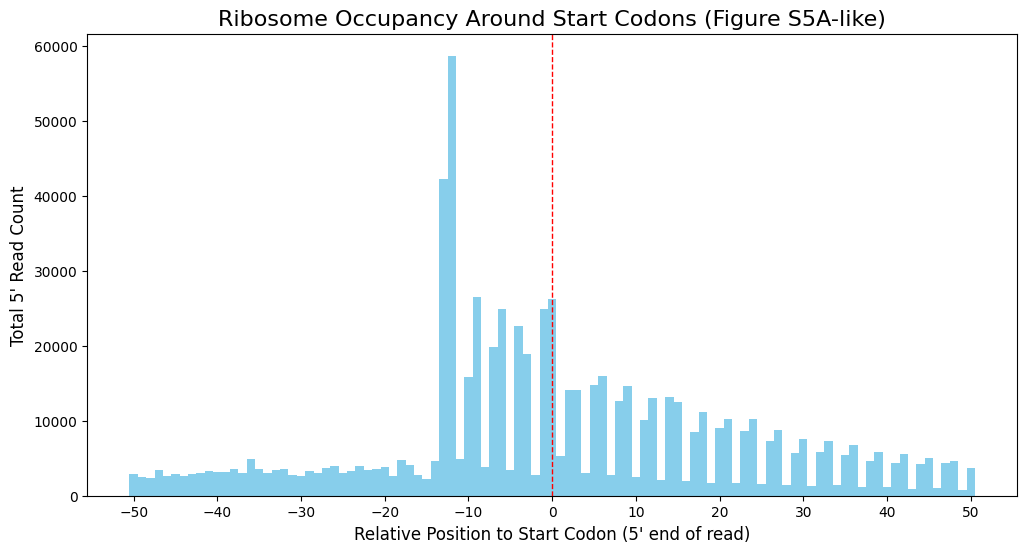

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define column names for the intersected file
# This file contains information from 'fivepcounts-RPF-siLuc.bed' (4 columns)
# and 'gencode-exons-containing-startcodon.bed' (6 columns).
column_names = [
    'read_chr', 'read_start', 'read_end', 'read_count',
    'exon_chr', 'exon_start', 'exon_end', 'transcript_id', 'start_codon_pos_0based', 'strand'
]

# Load the data into a pandas DataFrame
try:
    df = pd.read_csv(
        'fivepcounts-filtered-RPF-siLuc.txt',
        sep='\t',
        header=None,
        names=column_names
    )
except MemoryError:
    print("MemoryError: The 'fivepcounts-filtered-RPF-siLuc.txt' file is too large to load directly.")
    print("Consider processing it in chunks if this error occurs during execution.")
    raise # Re-raise the error to stop execution

# Calculate the relative position of the 5' end of the read to the start codon.
# 'read_start' is the 0-based start coordinate of the 5' end of the read.
# 'start_codon_pos_0based' is the 0-based start coordinate of the start codon.
# A positive value means the 5' end is downstream of the start codon.
df['relative_position'] = df['read_start'] - df['start_codon_pos_0based']

# Aggregate the read counts by relative position
# We sum the 'read_count' for each unique 'relative_position'.
rp_counts = df.groupby('relative_position')['read_count'].sum().reset_index()

# Filter the data to a common range around the start codon for visualization (-50 to +50).
# This range is typical for ribosome profiling plots around start codons.
min_pos = -50
max_pos = 50
rp_counts_filtered = rp_counts[
    (rp_counts['relative_position'] >= min_pos) &
    (rp_counts['relative_position'] <= max_pos)
].copy() # Use .copy() to prevent SettingWithCopyWarning

# Ensure all positions in the chosen range are present, filling missing counts with 0.
# This creates a continuous x-axis for the plot.
full_range = pd.DataFrame({'relative_position': range(min_pos, max_pos + 1)})
rp_counts_full = pd.merge(full_range, rp_counts_filtered, on='relative_position', how='left').fillna(0)

# Sort the data by relative position for correct plotting order.
rp_counts_full = rp_counts_full.sort_values('relative_position')

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))

# Use a bar plot to show ribosome occupancy (5' read counts) at each relative position.
ax.bar(
    rp_counts_full['relative_position'],
    rp_counts_full['read_count'],
    color='skyblue',
    width=1 # Bars represent single base positions
)

# Add a vertical red dashed line at relative_position 0 to mark the start codon.
ax.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Start Codon (ATG)')

# Customize the plot appearance for clarity.
ax.set_title('Ribosome Occupancy Around Start Codons (Figure S5A-like)', fontsize=16)
ax.set_xlabel('Relative Position to Start Codon (5\' end of read)', fontsize=12)
ax.set_ylabel('Total 5\' Read Count', fontsize=12)

# Set x-axis ticks at intervals of 10 for better readability.
ax.set_xticks(range(min_pos, max_pos + 1, 10))
ax.tick_params(axis='x', rotation=45, ha='right') # Rotate x-axis labels if they are dense.
ax.grid(axis='y', linestyle='--', alpha=0.7) # Add a horizontal grid for easier count reading.
ax.legend() # Display the legend for the start codon line.
plt.tight_layout() # Adjust plot layout to prevent labels from overlapping.
plt.show()